# Modelo 1 — Clasificador OCT (imágenes originales)

In [13]:
import os
import kagglehub
from pathlib import Path

import torch
import torch.nn as nn
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader

# Setea la carpeta data como default para almacenar los datasets descargados
os.environ["KAGGLEHUB_CACHE"] = "./data"

# ── Rutas ──────────────────────────────────────────────────────────────
path_clas = os.path.abspath('./data/datasets/paultimothymooney/kermany2018')
dir_kaggle_clas = 'paultimothymooney/kermany2018'

if os.access(path_clas, os.F_OK) is False:
    path = kagglehub.dataset_download(dir_kaggle_clas)
    path_clas = os.path.abspath(path)
else:
    print('El dataset ya ha sido descargado previamente.')


TRAIN_PATH  =  Path(os.path.join(path_clas,"versions/2/OCT2017 /train"))
VAL_PATH   = Path(os.path.join(path_clas,"versions/2/OCT2017 /val"))
TEST_PATH   = Path(os.path.join(path_clas,"versions/2/OCT2017 /test"))

print(f"Ruta de las imágenes TRAIN: {TRAIN_PATH}")
print(f"Ruta de las imágenes VAL: {VAL_PATH}")
print(f"Ruta de las imágenes TEST: {TEST_PATH}")


El dataset ya ha sido descargado previamente.
Ruta de las imágenes TRAIN: /content/data/datasets/paultimothymooney/kermany2018/versions/2/OCT2017 /train
Ruta de las imágenes VAL: /content/data/datasets/paultimothymooney/kermany2018/versions/2/OCT2017 /val
Ruta de las imágenes TEST: /content/data/datasets/paultimothymooney/kermany2018/versions/2/OCT2017 /test


In [14]:
from torch.utils.data import Subset
import numpy as np

# ── Transforms y DataLoaders ───────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# Usar solo 2000 imágenes de train y 32 de val para verificar que entrena

train_ds = datasets.ImageFolder(TRAIN_PATH, transform=train_transform)
val_ds   = datasets.ImageFolder(VAL_PATH, transform=val_transform)
test_ds  = datasets.ImageFolder(TEST_PATH, transform=val_transform)

indices_train = np.random.choice(len(train_ds), 2000, replace=False)
indices_val   = np.arange(len(val_ds))  # val ya tiene solo 32

train_loader = DataLoader(Subset(train_ds, indices_train), batch_size=16, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=0)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')
print(f'Clases: {train_ds.classes}')

Train: 83484 | Val: 32 | Test: 968
Clases: ['CNV', 'DME', 'DRUSEN', 'NORMAL']


In [15]:
# ── Modelo ─────────────────────────────────────────────────────────────
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(model.fc.in_features, 4)   # 4 clases: CNV, DME, DRUSEN, NORMAL

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)

# ── Loss + optimizer ───────────────────────────────────────────────────
loss_fn   = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print(f'Parámetros totales Modelo 1: {sum(p.numel() for p in model.parameters()):,}')
print(f'Parámetros entrenables:      {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Parámetros totales Modelo 1: 23,516,228
Parámetros entrenables:      23,516,228


In [16]:
print(device)
print(torch.cuda.is_available())

cuda
True


In [17]:
# ── Train loop ─────────────────────────────────────────────────────────
epochs    = 20
patience  = 5
best_val  = float('inf')
bad_epochs = 0

os.makedirs('modelos', exist_ok=True)
best_path = 'modelos/modelo1_resnet50.pth'

for epoch in range(epochs):

    # ── train ──
    model.train()
    train_loss = 0.0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss   = loss_fn(logits, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ── val ──
    model.eval()
    val_loss    = 0.0
    val_correct = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y   = x.to(device), y.to(device)
            logits = model(x)
            val_loss    += loss_fn(logits, y).item()
            val_correct += (logits.argmax(dim=1) == y).sum().item()

    val_loss /= len(val_loader)
    val_acc   = val_correct / len(val_loader.dataset)

    print(f'Epoch {epoch+1}/{epochs} - train loss: {train_loss:.4f} - val loss: {val_loss:.4f} - val acc: {val_acc:.4f}')

    # ── early stopping ──
    if val_loss < best_val - 1e-6:
        best_val   = val_loss
        bad_epochs = 0
        torch.save(model.state_dict(), best_path)
        print(f'  ✅ Mejoró val_loss. Guardado en {best_path}')
    else:
        bad_epochs += 1
        print(f'  ⏳ No mejoró. patience: {bad_epochs}/{patience}')

        if bad_epochs >= patience:
            print(f'🛑 Early stopping: {patience} épocas sin mejora.')
            break

print('Entrenamiento finalizado.')

Epoch 1/20 - train loss: 0.7985 - val loss: 0.4185 - val acc: 0.8438
  ✅ Mejoró val_loss. Guardado en modelos/modelo1_resnet50.pth
Epoch 2/20 - train loss: 0.3572 - val loss: 0.1803 - val acc: 0.9375
  ✅ Mejoró val_loss. Guardado en modelos/modelo1_resnet50.pth
Epoch 3/20 - train loss: 0.2586 - val loss: 0.1343 - val acc: 0.9375
  ✅ Mejoró val_loss. Guardado en modelos/modelo1_resnet50.pth
Epoch 4/20 - train loss: 0.1899 - val loss: 0.1607 - val acc: 0.9375
  ⏳ No mejoró. patience: 1/5
Epoch 5/20 - train loss: 0.1518 - val loss: 0.1970 - val acc: 0.9375
  ⏳ No mejoró. patience: 2/5
Epoch 6/20 - train loss: 0.1555 - val loss: 0.1866 - val acc: 0.8750
  ⏳ No mejoró. patience: 3/5
Epoch 7/20 - train loss: 0.1155 - val loss: 0.2327 - val acc: 0.9062
  ⏳ No mejoró. patience: 4/5
Epoch 8/20 - train loss: 0.1038 - val loss: 0.0891 - val acc: 0.9375
  ✅ Mejoró val_loss. Guardado en modelos/modelo1_resnet50.pth
Epoch 9/20 - train loss: 0.0940 - val loss: 0.0799 - val acc: 0.9375
  ✅ Mejoró val_

              precision    recall  f1-score   support

         CNV       0.98      0.98      0.98       242
         DME       0.98      1.00      0.99       242
      DRUSEN       1.00      0.98      0.99       242
      NORMAL       1.00      1.00      1.00       242

    accuracy                           0.99       968
   macro avg       0.99      0.99      0.99       968
weighted avg       0.99      0.99      0.99       968



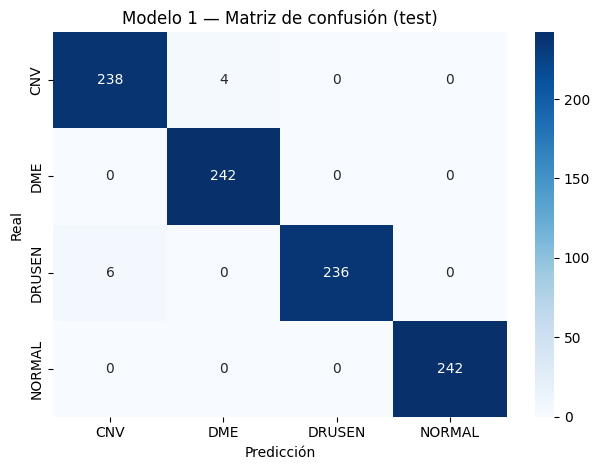

In [18]:
# ── Evaluación en test ─────────────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los mejores pesos
model.load_state_dict(torch.load(best_path, map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        all_preds.extend(model(x).argmax(dim=1).cpu().numpy())
        all_labels.extend(y.numpy())

class_names = ['CNV', 'DME', 'DRUSEN', 'NORMAL']
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Modelo 1 — Matriz de confusión (test)')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()